In [10]:
import pandas as pd

df = pd.read_csv("retail.csv")
print(df.head())
#inspect the first few rows of the dataframe




   OrderID        Date CustomerID   Region   Channel     Category  \
0  ORD0001  2026-03-23    CUST032  Mombasa  In-Store  Electronics   
1  ORD0002  2026-03-28    CUST005  Nairobi  In-Store  Electronics   
2  ORD0003  2026-03-06    CUST092   Nakuru  In-Store  Electronics   
3  ORD0004  2026-02-05    CUST044   Kisumu  In-Store  Electronics   
4  ORD0005  2026-01-14    CUST046   Kisumu  In-Store  Electronics   

             Product  Quantity  UnitPrice_KES  Revenue_KES PaymentMethod  
0     Wireless Mouse         3           1800         5400        M-Pesa  
1  Bluetooth Speaker         4           5200        20800        M-Pesa  
2  Bluetooth Speaker         2           5200        10400          Cash  
3           Keyboard         4           3200        12800          Card  
4         Power Bank         1           3500         3500        M-Pesa  


In [11]:
print(df.shape)

(300, 11)


There are 300 number of rows and 11 columns 

In [12]:

print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   OrderID        300 non-null    str  
 1   Date           300 non-null    str  
 2   CustomerID     300 non-null    str  
 3   Region         300 non-null    str  
 4   Channel        300 non-null    str  
 5   Category       300 non-null    str  
 6   Product        300 non-null    str  
 7   Quantity       300 non-null    int64
 8   UnitPrice_KES  300 non-null    int64
 9   Revenue_KES    300 non-null    int64
 10  PaymentMethod  300 non-null    str  
dtypes: int64(3), str(8)
memory usage: 45.2 KB
None


The main data types of the columns are str and int64. 

one row represents one transaction, and each column represents a different attribute of that transaction. The dataset contains 300 rows and 11 columns, which means there are 300 transactions recorded in the dataset, and each transaction has 11 attributes associated with it.

PROBLEM FACING

Stakeholder :
The manager who runs retail sales, in stores and online.

Decision it can support :
Choosing which regions and channels to put more marketing and stock into next quarter.
Unit of analysis is One row = one order or transaction . An order can include more than one unit of a product.

Task type:
Mainly descriptive and diagnostic; it explains what already happened (revenue, order count, average order size) and shows where regions or channels differ. It doesn't predict the future or tell you what to do next.

Limitations:
The data covers just three months and doesn't include costs, so we can only talk about revenue and order patterns, not profit. Three months also isn't long enough to be sure about seasonal trends.

CALCULATING THE KPI'S


In [13]:
#KP1 TOtal revenue in KES
total_revenue = df["Revenue_KES"].sum()
total_revenue

np.int64(3206450)

The total revenue represents the amount of sales generated across all transactions in the dataset.

In [14]:
#KP2 Total number of transactions
num_transactions = df["OrderID"].nunique()
num_transactions

300

This is the total sales volume (order count), which indicates how much customer activity the business handled, independent of order size.

In [15]:
#KP3 Average transaction value
average_transaction_value = df["Revenue_KES"].mean()
round(average_transaction_value, 2)

np.float64(10688.17)

In [16]:
kpi_summary = pd.DataFrame({
    "KPI": ["Total Revenue (KES)", "Number of Transactions", "Average Transaction Value (KES)"],
    "Value": [total_revenue, num_transactions, round(average_transaction_value, 2)]
})
kpi_summary

,KPI,Value
0,Total Revenue (KES),3206450.00
1,Number of Transactions,300.00
2,Average Transaction Value (KES),10688.17


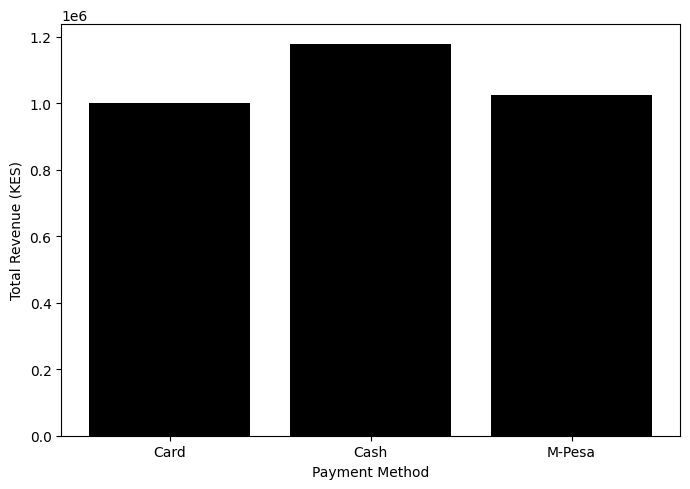

In [20]:
import matplotlib.pyplot as plt
Payment_by_revenue = df.groupby("PaymentMethod")["Revenue_KES"].sum()

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(Payment_by_revenue.index, Payment_by_revenue.values, color="black")
ax.set_xlabel("Payment Method")
ax.set_ylabel("Total Revenue (KES)")
plt.tight_layout()
plt.show()




This graph shows the total revenue generated by each payment method. It helps to identify which payment methods are contributing the most to the overall revenue.

This graph shows that the majority of revenue comes from mobile money payments, followed by card payments and cash on delivery. This insight can help the company focus on optimizing their mobile money payment process to further increase revenue.

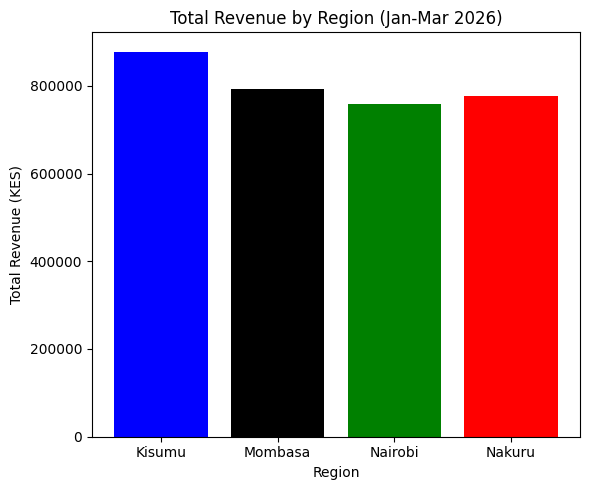

In [18]:
revenue_by_region = df.groupby("Region")["Revenue_KES"].sum()

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(revenue_by_region.index, revenue_by_region.values, color=["blue","black","green","red"])
ax.set_title("Total Revenue by Region (Jan-Mar 2026)")
ax.set_xlabel("Region")
ax.set_ylabel("Total Revenue (KES)")
plt.tight_layout()
plt.show()


This is  a bar chart showing the total revenue by region for the first quarter of 2026. The x-axis represents the different regions, while the y-axis represents the total revenue in Kenyan Shillings (KES). Each bar is colored differently to distinguish between the regions.



Kisumu generates the highest total revenue, narrowly ahead of Mombasa, Nakuru and Nairobi, which are all fairly close to one another revenue is spread fairly evenly across the four regions rather than concentrated in one, so regional marketing spend does not need to be sharply rebalanced based on this quarter alone.


CONCLUSION


Over January to March 2026, the business recorded 300 transactions generating the total revenue shown in
KPI 1, with an average order value shown in KPI 3. Revenue is fairly evenly spread across the four
regions (Kisumu slightly ahead), while cash  payments clearly outperform card and mpesa payments and  in
total revenue. These findings suggest the cash payment is the stronger current revenue driver
and that cash and card sales have room to grow, while no single region needs urgent rebalancing of
marketing spend based on this quarter alone. Because the data spans only one quarter and excludes
cost data, these findings describe what happened, not why, and should not be used alone to
conclude long-term seasonal trends or profitability.